In [16]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

import os

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg') # Removed to allow interactive plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# Classification
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Anomaly Detection
from sklearn.ensemble import IsolationForest

# Association Rules
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Output directory for plots
PLOT_DIR = os.path.join(os.getcwd(), 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

def save_fig(name):
    """Save current figure to the plots directory."""
    path = os.path.join(PLOT_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Saved: {path}')

sns.set_theme(style='whitegrid', palette='Set2')
print('All libraries imported successfully.')
print(f'Plots will be saved to: {PLOT_DIR}')

All libraries imported successfully.
Plots will be saved to: /content/plots


In [4]:
df = pd.read_csv('Public.csv')
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(3)

Dataset shape: (342075, 102)
Rows: 342,075 | Columns: 102


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NR_INJURIES,NR_FATALITIES,COMMENTS,IMAGE,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER
0,608242,1996-06-22,6,1996,NaN,NaN,KSMF,SACRAMENTO INTL,38.69542,-121.59077,...,NaN,NaN,/Legacy Record 100001/,False,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
1,608243,1996-06-26,6,1996,NaN,NaN,KDEN,DENVER INTL AIRPORT,39.85841,-104.667,...,NaN,NaN,/Legacy Record 100002/,False,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
2,608244,1996-07-01,7,1996,NaN,NaN,KOMA,EPPLEY AIRFIELD,41.30252,-95.89417,...,NaN,NaN,/Legacy Record 100003/,False,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0


In [6]:
print('Data types:')
print(df.dtypes.value_counts())
print()
print('Column names:')
print(df.columns.tolist())

Data types:
object     42
int64      41
float64    18
bool        1
Name: count, dtype: int64

Column names:
['INDEX_NR', 'INCIDENT_DATE', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'AIRPORT', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'LOCATION', 'OPID', 'OPERATOR', 'REG', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'AOS', 'COST_REPAIRS', 'COST_OTHER', 'COST_REPAIRS_INFL_ADJ', 'COST_OTHER_INFL_ADJ', 'INGESTED_OTHER', 'INDICATED_DAMAGE', 'DAMAGE_LEVEL', 'STR_RAD', 'DAM_RAD', 'STR_WINDSHLD', 'DAM_WINDSHLD', 'STR_NOSE', 'DAM_NOSE', 'STR_ENG1', 'DAM_ENG1', 'ING_ENG1', 'STR_ENG2', 'DAM_ENG2', 'ING_ENG2', 'STR_ENG3', 'DAM_ENG3', 'ING_ENG3', 'STR_ENG4', 'DAM_ENG4', 'ING_ENG4', 'STR_PROP', 'DAM_PROP', 'STR_WING_ROT', 'DAM_WING_ROT', 'STR_FUSE', 'DAM_FUSE', 'STR_LG', 'DAM_LG', '

In [7]:
# Missing value analysis
missing     = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing_df)} / {df.shape[1]}')
missing_df.head(20)


Columns with missing values: 51 / 102


,Missing Count,Missing %
NR_FATALITIES,342050,99.99
NR_INJURIES,341775,99.91
BIRD_BAND_NUMBER,341292,99.77
EFFECT_OTHER,339393,99.22
ENG_4_POS,338457,98.94
COST_REPAIRS_INFL_ADJ,336698,98.43
COST_REPAIRS,336698,98.43
COST_OTHER_INFL_ADJ,336592,98.40
COST_OTHER,336592,98.40
ENROUTE_STATE,336123,98.26


In [8]:
print('Basic statistics for numeric columns:')
df.describe().T


Basic statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
INDEX_NR,342075.0,1.032540e+06,3.867265e+05,608242.00,705732.5,805620.0,1441665.5,1827858.0
INCIDENT_MONTH,342075.0,7.225030e+00,2.752573e+00,1.00,5.0,8.0,9.0,12.0
INCIDENT_YEAR,342075.0,2.013656e+03,8.995977e+00,1990.00,2008.0,2016.0,2021.0,2026.0
EMA,228075.0,1.929591e+01,1.056815e+01,1.00,10.0,22.0,31.0,47.0
EMO,216009.0,8.148304e+00,1.149281e+01,0.00,1.0,4.0,10.0,97.0
AC_MASS,244732.0,3.558309e+00,8.651679e-01,1.00,3.0,4.0,4.0,5.0
NUM_ENGS,244444.0,2.003854e+00,4.085882e-01,1.00,2.0,2.0,2.0,4.0
ENG_1_POS,244419.0,2.717878e+00,2.116948e+00,1.00,1.0,1.0,5.0,7.0
ENG_2_POS,227978.0,2.541579e+00,1.956979e+00,1.00,1.0,1.0,5.0,7.0
ENG_3_POS,13641.0,2.900814e+00,1.938437e+00,1.00,1.0,1.0,5.0,6.0


In [9]:
dmg_map    = {'N': 'No Damage', 'M': 'Minor', 'M?': 'Minor?', 'S': 'Substantial', 'D': 'Destroyed'}
dmg_counts = df['DAMAGE_LEVEL'].value_counts()
dmg_counts.index = [dmg_map.get(x, x) for x in dmg_counts.index]
print('Damage Level Distribution:')
print(dmg_counts.to_string())
n_damaged = df['DAMAGE_LEVEL'].isin(['M', 'M?', 'S', 'D']).sum()
n_no_dmg  = (df['DAMAGE_LEVEL'] == 'N').sum()
print(f'\nDamaged (M/M?/S/D): {n_damaged:,}  ({n_damaged/len(df)*100:.1f}%)')
print(f'No Damage (N):       {n_no_dmg:,}  ({n_no_dmg/len(df)*100:.1f}%)')


Damage Level Distribution:
No Damage      199290
Minor            8767
Minor?           8489
Substantial      4387
Destroyed          89

Damaged (M/M?/S/D): 21,732  (6.4%)
No Damage (N):       199,290  (58.3%)


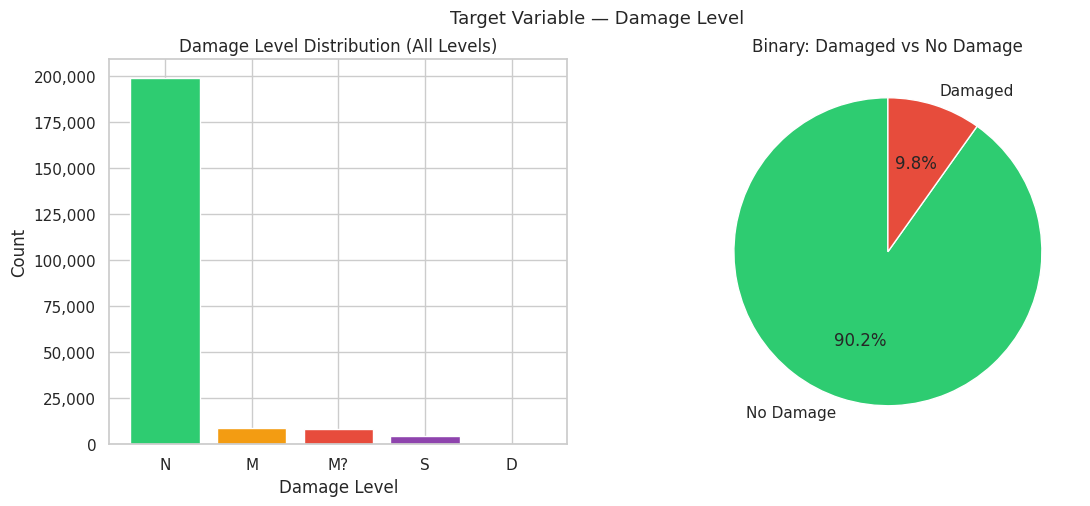

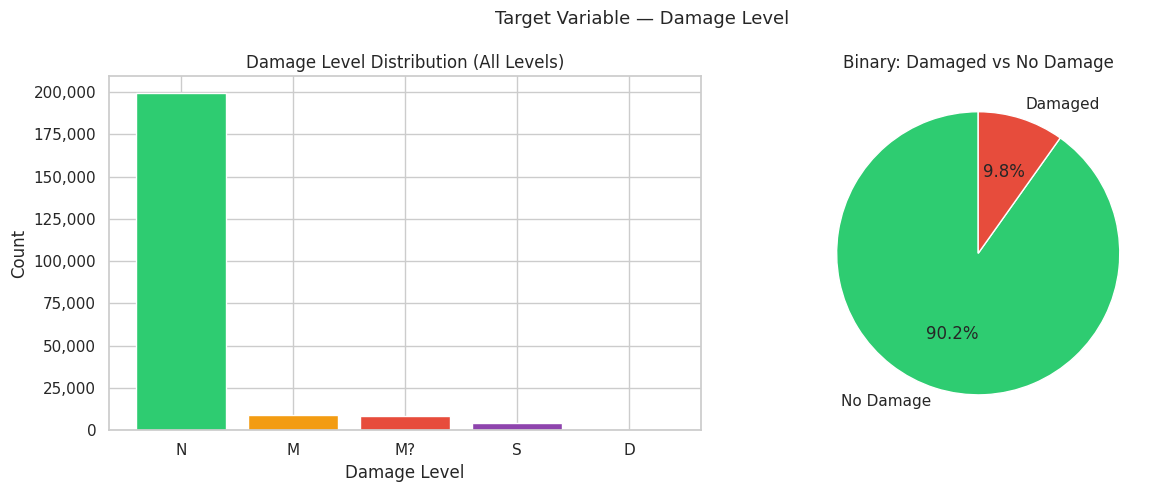

Saved: /content/plots/damage_level_distribution.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dmg_raw    = df['DAMAGE_LEVEL'].value_counts()
bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad', '#95a5a6']
axes[0].bar(dmg_raw.index, dmg_raw.values, color=bar_colors[:len(dmg_raw)], edgecolor='white')
axes[0].set_title('Damage Level Distribution (All Levels)')
axes[0].set_xlabel('Damage Level')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

bin_counts = pd.Series({
    'No Damage': (df['DAMAGE_LEVEL'] == 'N').sum(),
    'Damaged':    df['DAMAGE_LEVEL'].isin(['M', 'M?', 'S', 'D']).sum()
})
axes[1].pie(bin_counts, labels=bin_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Binary: Damaged vs No Damage')

plt.suptitle('Target Variable — Damage Level', fontsize=13)
plt.tight_layout()
plt.show() # Display the plot
save_fig('damage_level_distribution.png')

In [18]:
if 'INCIDENT_DATE' in df.columns:
    df['YEAR'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce').dt.year
elif 'INCIDENT_YEAR' in df.columns:
    df['YEAR'] = pd.to_numeric(df['INCIDENT_YEAR'], errors='coerce')
else:
    year_cols = [c for c in df.columns if 'YEAR' in c.upper()]
    df['YEAR'] = pd.to_numeric(df[year_cols[0]], errors='coerce') if year_cols else None

yearly = df.groupby('YEAR').size().reset_index(name='COUNT')
yearly = yearly[yearly['YEAR'].between(1990, 2024)].reset_index(drop=True)
print(f'Year range: {int(yearly.YEAR.min())} - {int(yearly.YEAR.max())}')
print(yearly.tail(10).to_string(index=False))


Year range: 1990 - 2024
 YEAR  COUNT
 2015  13777
 2016  13377
 2017  14757
 2018  16206
 2019  17348
 2020  11625
 2021  15641
 2022  17223
 2023  19624
 2024  22370


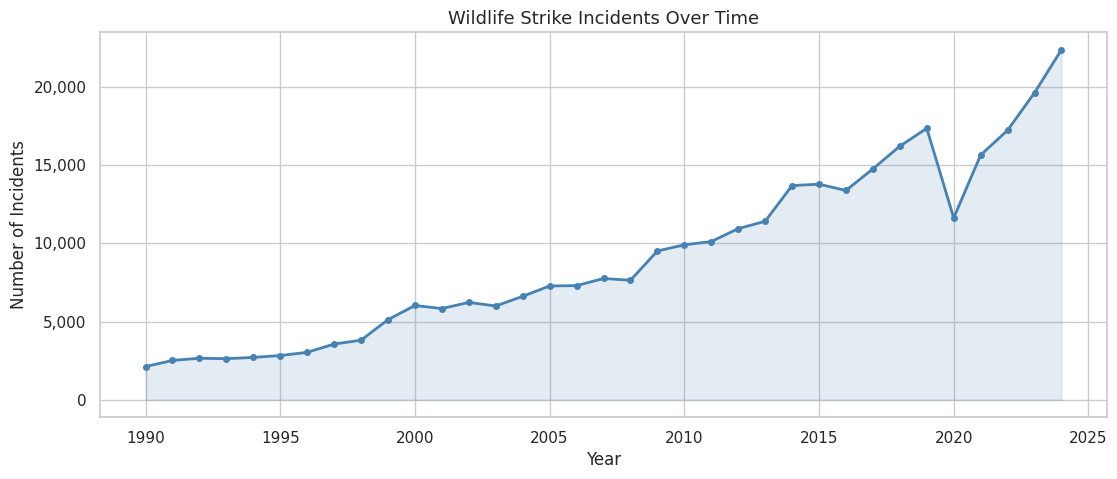

Saved: /content/plots/incidents_over_time.png


In [20]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(yearly['YEAR'], yearly['COUNT'], marker='o', markersize=4, linewidth=2, color='steelblue')
ax.fill_between(yearly['YEAR'], yearly['COUNT'], alpha=0.15, color='steelblue')
ax.set_title('Wildlife Strike Incidents Over Time', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()
save_fig('incidents_over_time.png')


In [21]:
phase_counts = df['PHASE_OF_FLIGHT'].value_counts().head(10)
print('Top 10 Phases of Flight:')
print(phase_counts.to_string())

phase_dmg = df[df['DAMAGE_LEVEL'].isin(['N','M','M?','S','D'])].copy()
phase_dmg['DAMAGED'] = (phase_dmg['DAMAGE_LEVEL'] != 'N').astype(int)
phase_rate = phase_dmg.groupby('PHASE_OF_FLIGHT')['DAMAGED'].mean().sort_values(ascending=False).head(10)
print('\nDamage rate by phase:')
print(phase_rate.round(3).to_string())


Top 10 Phases of Flight:
PHASE_OF_FLIGHT
Approach        88031
Landing Roll    37483
Take-off Run    34511
Climb           30534
En Route         6236
Departure        3980
Descent          2952
Local            1502
Arrival          1079
Taxi              797

Damage rate by phase:
PHASE_OF_FLIGHT
En Route        0.307
Climb           0.162
Descent         0.149
Local           0.104
Take-off Run    0.096
Approach        0.090
Landing Roll    0.062
Taxi            0.061
Arrival         0.059
Departure       0.052


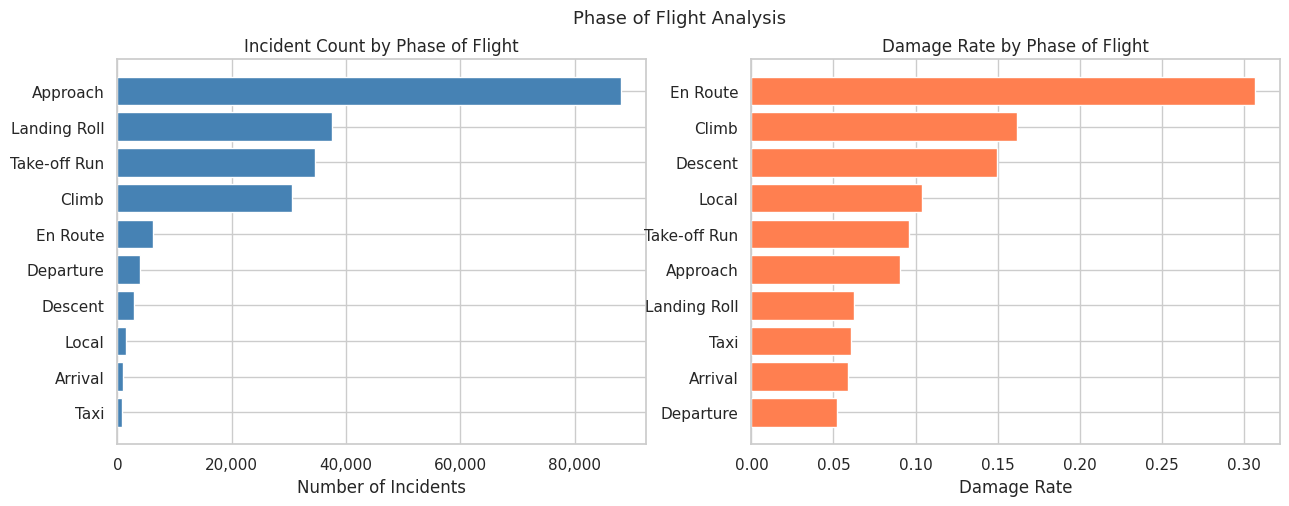

Saved: /content/plots/phase_of_flight_analysis.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

phase_counts = df['PHASE_OF_FLIGHT'].value_counts().head(10)
axes[0].barh(phase_counts.index[::-1], phase_counts.values[::-1], color='steelblue')
axes[0].set_title('Incident Count by Phase of Flight')
axes[0].set_xlabel('Number of Incidents')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

phase_dmg = df[df['DAMAGE_LEVEL'].isin(['N','M','M?','S','D'])].copy()
phase_dmg['DAMAGED'] = (phase_dmg['DAMAGE_LEVEL'] != 'N').astype(int)
phase_rate = phase_dmg.groupby('PHASE_OF_FLIGHT')['DAMAGED'].mean().sort_values(ascending=False).head(10)
axes[1].barh(phase_rate.index[::-1], phase_rate.values[::-1], color='coral')
axes[1].set_title('Damage Rate by Phase of Flight')
axes[1].set_xlabel('Damage Rate')

plt.suptitle('Phase of Flight Analysis', fontsize=13)
plt.show()
save_fig('phase_of_flight_analysis.png')


In [23]:
size_counts = df['SIZE'].value_counts()
print('Wildlife Size Distribution:')
print(size_counts.to_string())

size_dmg = df[df['DAMAGE_LEVEL'].isin(['N','M','M?','S','D'])].copy()
size_dmg['DAMAGED'] = (size_dmg['DAMAGE_LEVEL'] != 'N').astype(int)
size_rate = size_dmg.groupby('SIZE')['DAMAGED'].mean().sort_values(ascending=False)
print('\nDamage rate by size:')
print(size_rate.round(3).to_string())


Wildlife Size Distribution:
SIZE
Small     211234
Medium     72962
Large      20476

Damage rate by size:
SIZE
Large     0.478
Medium    0.166
Small     0.035


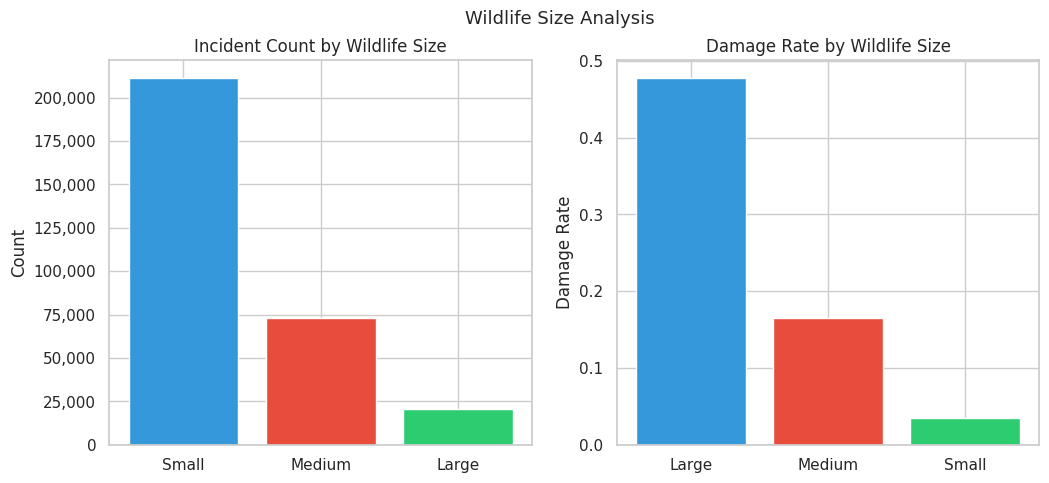

Saved: /content/plots/wildlife_size_analysis.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sz_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

size_counts = df['SIZE'].value_counts()
axes[0].bar(size_counts.index, size_counts.values,
            color=sz_colors[:len(size_counts)], edgecolor='white')
axes[0].set_title('Incident Count by Wildlife Size')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

size_dmg = df[df['DAMAGE_LEVEL'].isin(['N','M','M?','S','D'])].copy()
size_dmg['DAMAGED'] = (size_dmg['DAMAGE_LEVEL'] != 'N').astype(int)
size_rate = size_dmg.groupby('SIZE')['DAMAGED'].mean()
axes[1].bar(size_rate.index, size_rate.values,
            color=sz_colors[:len(size_rate)], edgecolor='white')
axes[1].set_title('Damage Rate by Wildlife Size')
axes[1].set_ylabel('Damage Rate')

plt.suptitle('Wildlife Size Analysis', fontsize=13)
plt.show()
save_fig('wildlife_size_analysis.png')


Top 15 Species (column: SPECIES):
SPECIES
Unknown bird - small     54752
Unknown bird - medium    39359
Unknown bird             36935
Mourning dove            17887
Barn swallow             11699
Killdeer                 11416
American kestrel         10459
Horned lark               9862
Gulls                     7659
European starling         6967
Eastern meadowlark        5254
Rock pigeon               4758
Red-tailed hawk           4509
Sparrows                  4405
Unknown bird - large      3974


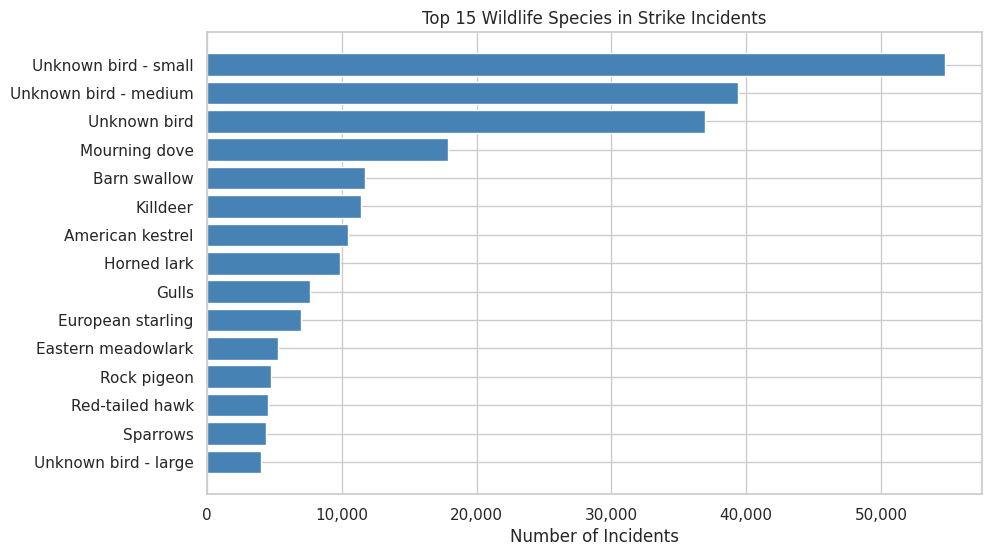

Saved: /content/plots/top_species.png


In [26]:
species_col = next((c for c in ['SPECIES', 'SPECIES_ID', 'WILDLIFE_SPECIES'] if c in df.columns), None)

if species_col:
    top_species = df[species_col].value_counts().head(15)
    print(f'Top 15 Species (column: {species_col}):')
    print(top_species.to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_species.index[::-1], top_species.values[::-1], color='steelblue')
    ax.set_title('Top 15 Wildlife Species in Strike Incidents')
    ax.set_xlabel('Number of Incidents')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.show()
    save_fig('top_species.png')
else:
    print('Species column not found in dataset. Skipping.')


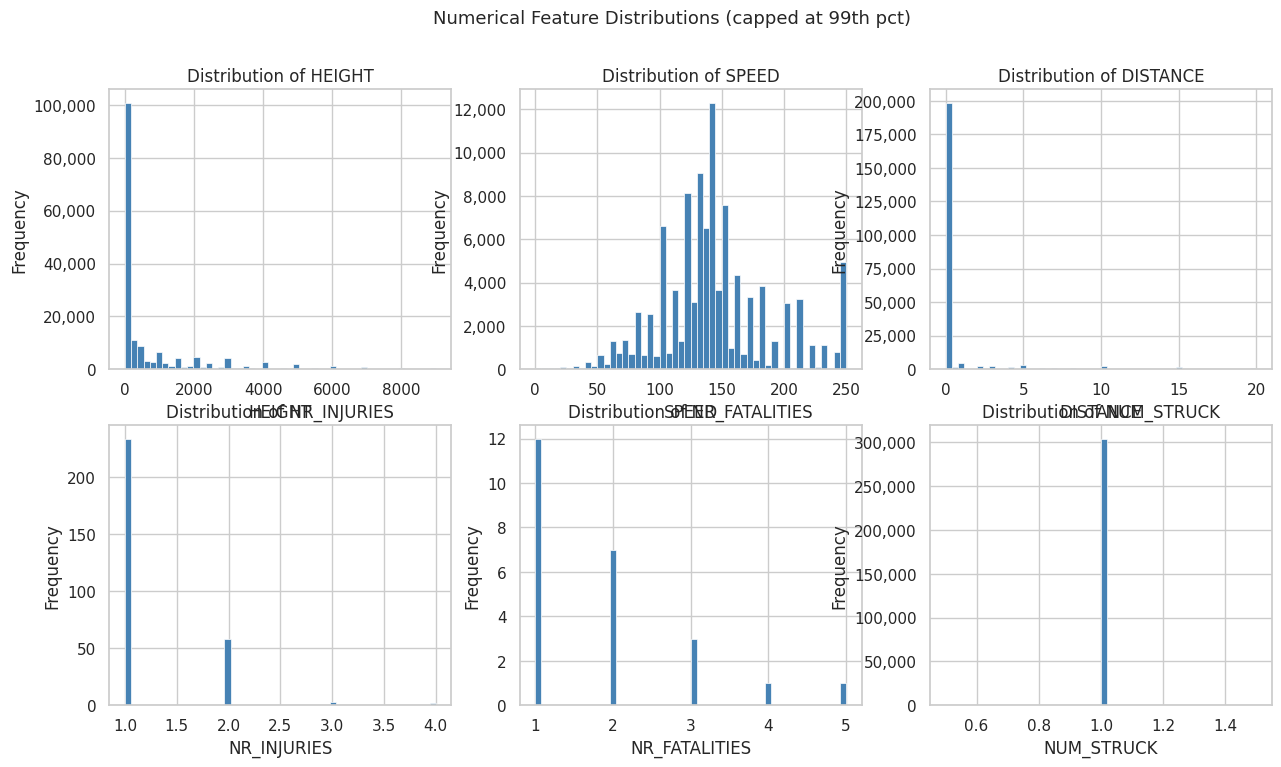

Saved: /content/plots/numerical_distributions.png


In [27]:
num_eda = ["HEIGHT","SPEED","DISTANCE","NR_INJURIES","NR_FATALITIES","NUM_STRUCK"]
num_eda = [c for c in num_eda if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_eda):
    data = pd.to_numeric(df[col], errors="coerce").dropna().values
    q99 = float(np.percentile(data, 99))
    data = data[data <= q99]
    axes[i].hist(data, bins=50, color="steelblue", edgecolor="white", linewidth=0.5)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col); axes[i].set_ylabel("Frequency")
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f"{int(x):,}"))
for j in range(len(num_eda), len(axes)): axes[j].set_visible(False)
plt.suptitle("Numerical Feature Distributions (capped at 99th pct)", fontsize=13)
plt.show()
save_fig("numerical_distributions.png")

/tmp/ipykernel_544/1207086294.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["No Dmg","Minor","Subst.","Destr."], patch_artist=True)
/tmp/ipykernel_544/1207086294.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["No Dmg","Minor","Subst.","Destr."], patch_artist=True)


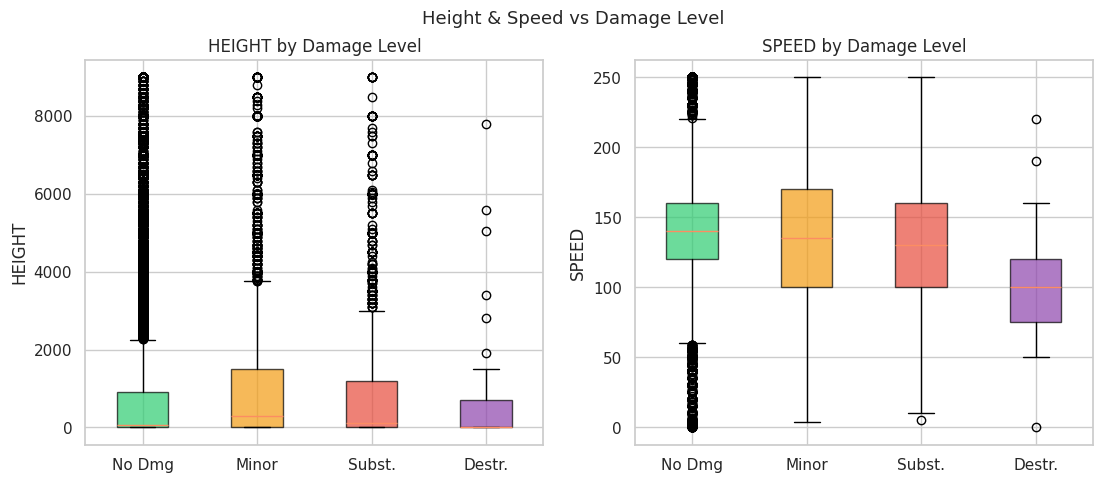

Saved: /content/plots/height_speed_by_damage.png


In [28]:
bdf = df[df["DAMAGE_LEVEL"].isin(["N","M","S","D"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ["HEIGHT","SPEED"]):
    bdf[col] = pd.to_numeric(bdf[col], errors="coerce")
    q99 = float(bdf[col].quantile(0.99))
    tmp = bdf[bdf[col].notna() & (bdf[col] <= q99)]
    groups = [tmp[tmp["DAMAGE_LEVEL"]==lvl][col].values for lvl in ["N","M","S","D"]]
    bp = ax.boxplot(groups, labels=["No Dmg","Minor","Subst.","Destr."], patch_artist=True)
    bp_c = ["#2ecc71","#f39c12","#e74c3c","#8e44ad"]
    for patch, color in zip(bp["boxes"], bp_c):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(f"{col} by Damage Level"); ax.set_ylabel(col)
plt.suptitle("Height & Speed vs Damage Level", fontsize=13)
plt.show()
save_fig("height_speed_by_damage.png")

Top 20 States by Incidents:
STATE
TX    30647
FL    24945
CA    23908
NY    16083
CO    14980
IL    13810
TN    10432
OH     9099
PA     9056
MI     8472
NJ     8022
KY     7840
MO     7381
NC     7243
GA     6621
HI     5648
FN     5127
IN     5002
DC     4856
WA     4843


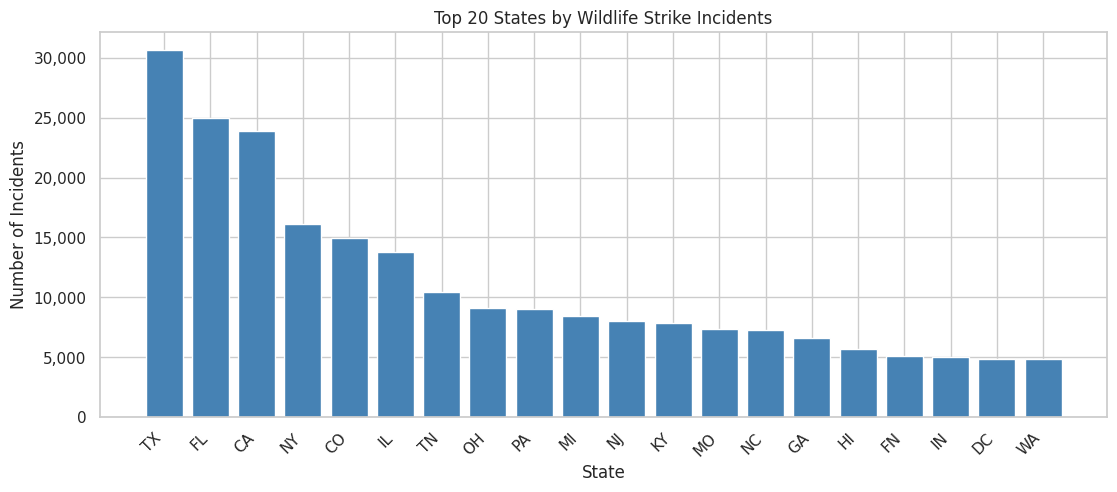

Saved: /content/plots/geographic_distribution.png


In [29]:
if 'STATE' in df.columns:
    state_counts = df['STATE'].value_counts().head(20)
    print('Top 20 States by Incidents:')
    print(state_counts.to_string())

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(state_counts.index, state_counts.values, color='steelblue', edgecolor='white')
    ax.set_title('Top 20 States by Wildlife Strike Incidents')
    ax.set_xlabel('State')
    ax.set_ylabel('Number of Incidents')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.xticks(rotation=45, ha='right')
    plt.show()
    save_fig('geographic_distribution.png')
else:
    airport_col = next((c for c in ['AIRPORT_ID','AIRPORT','ATYPE'] if c in df.columns), None)
    if airport_col:
        top_airports = df[airport_col].value_counts().head(15)
        print(f'Top 15 Airports (column: {airport_col}):')
        print(top_airports.to_string())
    else:
        print('State/Airport column not found.')


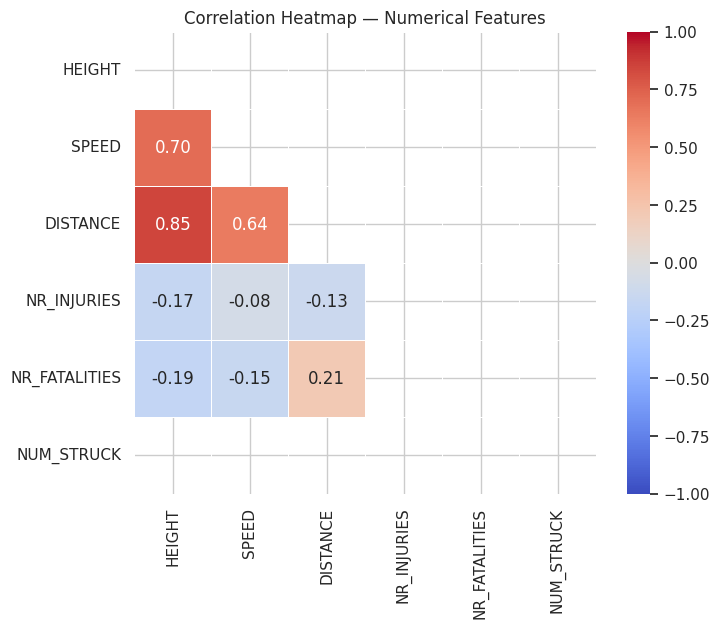

Saved: /content/plots/correlation_heatmap.png


In [30]:
num_cols    = ['HEIGHT', 'SPEED', 'DISTANCE', 'NR_INJURIES', 'NR_FATALITIES', 'NUM_STRUCK']
num_cols    = [c for c in num_cols if c in df.columns]
corr_df     = df[num_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Numerical Features')
plt.show()
save_fig('correlation_heatmap.png')


In [31]:
print('Step 1 - Define target variable')
df_model = df[df['DAMAGE_LEVEL'].isin(['N', 'M', 'M?', 'S', 'D'])].copy()
df_model['DAMAGE_LEVEL'] = df_model['DAMAGE_LEVEL'].replace({'M?': 'M'})
df_model['DAMAGED'] = (df_model['DAMAGE_LEVEL'] != 'N').astype(int)

print(f'Model dataset: {df_model.shape[0]:,} rows')
print(df_model['DAMAGED'].value_counts().rename({0: 'No Damage', 1: 'Damaged'}).to_string())
print(f'Damage rate: {df_model["DAMAGED"].mean():.2%}')


Step 1 - Define target variable
Model dataset: 221,022 rows
DAMAGED
No Damage    199290
Damaged       21732
Damage rate: 9.83%


In [32]:
print('Step 2 - Feature selection and label encoding')

NUM_FEATURES = ['HEIGHT', 'SPEED', 'DISTANCE', 'AC_MASS', 'NR_ENGINES', 'NUM_STRUCK']
NUM_FEATURES = [c for c in NUM_FEATURES if c in df_model.columns]

CAT_FEATURES = ['SIZE', 'PHASE_OF_FLIGHT', 'TIME_OF_DAY', 'AC_CLASS', 'SEASON']
CAT_FEATURES = [c for c in CAT_FEATURES if c in df_model.columns]

print(f'Numerical features ({len(NUM_FEATURES)}): {NUM_FEATURES}')
print(f'Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}')

le = LabelEncoder()
for col in CAT_FEATURES:
    df_model[col + '_ENC'] = le.fit_transform(df_model[col].astype(str).fillna('Unknown'))

ENC_FEATURES = [c + '_ENC' for c in CAT_FEATURES]
FEATURES = NUM_FEATURES + ENC_FEATURES
print(f'Total features: {len(FEATURES)}: {FEATURES}')


Step 2 - Feature selection and label encoding
Numerical features (5): ['HEIGHT', 'SPEED', 'DISTANCE', 'AC_MASS', 'NUM_STRUCK']
Categorical features (4): ['SIZE', 'PHASE_OF_FLIGHT', 'TIME_OF_DAY', 'AC_CLASS']
Total features: 9: ['HEIGHT', 'SPEED', 'DISTANCE', 'AC_MASS', 'NUM_STRUCK', 'SIZE_ENC', 'PHASE_OF_FLIGHT_ENC', 'TIME_OF_DAY_ENC', 'AC_CLASS_ENC']


In [33]:
print('Step 3 - Impute missing values and build X, y')

X_raw = df_model[FEATURES].apply(pd.to_numeric, errors='coerce')
y     = df_model['DAMAGED'].values

imputer = SimpleImputer(strategy='median')
X       = imputer.fit_transform(X_raw)

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print(f'Damage rate in y: {y.mean():.2%}')
print(f'Any NaN remaining: {np.isnan(X).any()}')


Step 3 - Impute missing values and build X, y
X shape: (221022, 9)  |  y shape: (221022,)
Damage rate in y: 9.83%
Any NaN remaining: False


In [34]:
print('Step 4 - Stratified 80/20 train/test split')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Sub-sample for KNN / SVM / Anomaly detection (cap at 50k for speed)
MAX_TRAIN = 50_000
rng = np.random.RandomState(42)
if len(X_train) > MAX_TRAIN:
    idx_s     = rng.choice(len(X_train), MAX_TRAIN, replace=False)
    X_train_s = X_train[idx_s]
    y_train_s = y_train[idx_s]
else:
    X_train_s = X_train
    y_train_s = y_train

X_tr_s = X_train_s  # alias used in anomaly cell-69

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train sample (SVM/KNN/Anomaly): {X_train_s.shape}')


Step 4 - Stratified 80/20 train/test split
Train: (176817, 9)  |  Test: (44205, 9)
Train sample (SVM/KNN/Anomaly): (50000, 9)


In [35]:
print('Step 5 - StandardScaler')

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)
X_train_s_sc = scaler.transform(X_train_s)   # scaled sample

print('Scaling complete.')
print(f'  X_train_sc   : {X_train_sc.shape}')
print(f'  X_test_sc    : {X_test_sc.shape}')
print(f'  X_train_s_sc : {X_train_s_sc.shape}')
print()
print('Preprocessing done. Key variables:')
print(f'  X {X.shape}, y {y.shape}, FEATURES={FEATURES}')


Step 5 - StandardScaler
Scaling complete.
  X_train_sc   : (176817, 9)
  X_test_sc    : (44205, 9)
  X_train_s_sc : (50000, 9)

Preprocessing done. Key variables:
  X (221022, 9), y (221022,), FEATURES=['HEIGHT', 'SPEED', 'DISTANCE', 'AC_MASS', 'NUM_STRUCK', 'SIZE_ENC', 'PHASE_OF_FLIGHT_ENC', 'TIME_OF_DAY_ENC', 'AC_CLASS_ENC']


In [36]:
results = []   # collect metrics for all classifiers
print('Classification setup complete.')
print(f'Train: {X_train.shape[0]:,} samples  ({y_train.mean():.1%} damaged)')
print(f'Test : {X_test.shape[0]:,}  samples  ({y_test.mean():.1%} damaged)')


Classification setup complete.
Train: 176,817 samples  (9.8% damaged)
Test : 44,205  samples  (9.8% damaged)


In [37]:
print('--- Decision Tree ----------------------------------------')
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt  = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt   = f1_score(y_test, y_pred_dt, zero_division=0)

print(f'Accuracy : {acc_dt:.4f}')
print(f'Precision: {prec_dt:.4f}')
print(f'Recall   : {rec_dt:.4f}')
print(f'F1-Score : {f1_dt:.4f}')

results.append({'Model': 'Decision Tree', 'Accuracy': acc_dt,
                'Precision': prec_dt, 'Recall': rec_dt, 'F1': f1_dt})


--- Decision Tree ----------------------------------------
Accuracy : 0.9123
Precision: 0.6535
Recall   : 0.2292
F1-Score : 0.3394


              precision    recall  f1-score   support

   No Damage       0.92      0.99      0.95     39859
     Damaged       0.65      0.23      0.34      4346

    accuracy                           0.91     44205
   macro avg       0.79      0.61      0.65     44205
weighted avg       0.90      0.91      0.89     44205



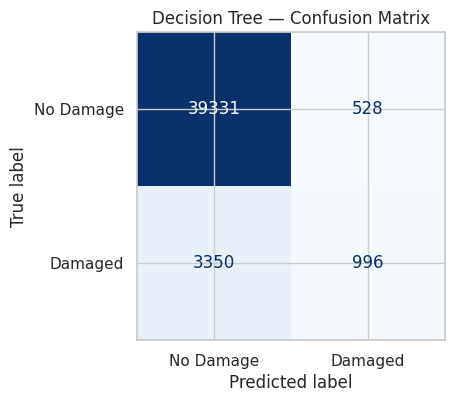

Saved: /content/plots/dt_confusion_matrix.png


In [39]:
print(classification_report(y_test, y_pred_dt, target_names=['No Damage', 'Damaged']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=['No Damage', 'Damaged']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Decision Tree — Confusion Matrix')
plt.show()
save_fig('dt_confusion_matrix.png')


In [40]:
feat_imp = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('Top 10 Feature Importances:')
print(feat_imp.head(10).round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.head(10).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Decision Tree — Top 10 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
save_fig('dt_feature_importance.png')


Top 10 Feature Importances:
SIZE_ENC               0.6334
AC_MASS                0.1730
HEIGHT                 0.0868
SPEED                  0.0378
PHASE_OF_FLIGHT_ENC    0.0353
TIME_OF_DAY_ENC        0.0247
DISTANCE               0.0051
AC_CLASS_ENC           0.0037
NUM_STRUCK             0.0000
Saved: /content/plots/dt_feature_importance.png


In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
print(f'Decision Tree 5-Fold CV F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Per-fold: {np.round(cv_scores, 4)}')


Decision Tree 5-Fold CV F1: 0.3309 +/- 0.0066
Per-fold: [0.3358 0.321  0.333  0.3389 0.3257]


In [42]:
print('--- Naive Bayes ------------------------------------------')
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
y_pred_nb = nb.predict(X_test_sc)

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0)
rec_nb  = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb   = f1_score(y_test, y_pred_nb, zero_division=0)

print(f'Accuracy : {acc_nb:.4f}')
print(f'Precision: {prec_nb:.4f}')
print(f'Recall   : {rec_nb:.4f}')
print(f'F1-Score : {f1_nb:.4f}')
print()
print(classification_report(y_test, y_pred_nb, target_names=['No Damage', 'Damaged']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nb),
                       display_labels=['No Damage', 'Damaged']).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Naive Bayes — Confusion Matrix')
plt.tight_layout()
save_fig('nb_confusion_matrix.png')

results.append({'Model': 'Naive Bayes', 'Accuracy': acc_nb,
                'Precision': prec_nb, 'Recall': rec_nb, 'F1': f1_nb})


--- Naive Bayes ------------------------------------------
Accuracy : 0.8605
Precision: 0.3019
Recall   : 0.3194
F1-Score : 0.3104

              precision    recall  f1-score   support

   No Damage       0.93      0.92      0.92     39859
     Damaged       0.30      0.32      0.31      4346

    accuracy                           0.86     44205
   macro avg       0.61      0.62      0.62     44205
weighted avg       0.86      0.86      0.86     44205

Saved: /content/plots/nb_confusion_matrix.png


In [43]:
print('--- K-Nearest Neighbors ----------------------------------')
k_values, f1_vals = [3, 5, 7, 9, 11, 15], []

for k in k_values:
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k, n_jobs=-1),
                        X_train_s_sc, y_train_s, cv=3, scoring='f1')
    f1_vals.append(s.mean())
    print(f'K={k:2d}: F1={s.mean():.4f}')

best_k = k_values[int(np.argmax(f1_vals))]
print(f'\nBest K: {best_k}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, f1_vals, marker='o', color='teal')
ax.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
ax.set_title('KNN — F1 Score vs K')
ax.set_xlabel('K'); ax.set_ylabel('F1 Score')
ax.legend()
plt.tight_layout()
save_fig('knn_k_selection.png')


--- K-Nearest Neighbors ----------------------------------
K= 3: F1=0.3242
K= 5: F1=0.3314
K= 7: F1=0.3347
K= 9: F1=0.3300
K=11: F1=0.3195
K=15: F1=0.3208

Best K: 7
Saved: /content/plots/knn_k_selection.png


In [44]:
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_s_sc, y_train_s)
y_pred_knn = knn.predict(X_test_sc)

acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, zero_division=0)
rec_knn  = recall_score(y_test, y_pred_knn, zero_division=0)
f1_knn   = f1_score(y_test, y_pred_knn, zero_division=0)

print(f'KNN (K={best_k}) Results:')
print(f'Accuracy : {acc_knn:.4f}')
print(f'Precision: {prec_knn:.4f}')
print(f'Recall   : {rec_knn:.4f}')
print(f'F1-Score : {f1_knn:.4f}')
print()
print(classification_report(y_test, y_pred_knn, target_names=['No Damage', 'Damaged']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn),
                       display_labels=['No Damage', 'Damaged']).plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'KNN (K={best_k}) — Confusion Matrix')
plt.tight_layout()
save_fig('knn_confusion_matrix.png')

results.append({'Model': f'KNN (K={best_k})', 'Accuracy': acc_knn,
                'Precision': prec_knn, 'Recall': rec_knn, 'F1': f1_knn})


KNN (K=7) Results:
Accuracy : 0.9074
Precision: 0.5688
Recall   : 0.2388
F1-Score : 0.3364

              precision    recall  f1-score   support

   No Damage       0.92      0.98      0.95     39859
     Damaged       0.57      0.24      0.34      4346

    accuracy                           0.91     44205
   macro avg       0.75      0.61      0.64     44205
weighted avg       0.89      0.91      0.89     44205

Saved: /content/plots/knn_confusion_matrix.png


In [45]:
print('--- Support Vector Machine (RBF) -------------------------')
print(f'Training on {len(X_train_s_sc):,} samples (sub-sample for speed)')

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_s_sc, y_train_s)
y_pred_svm = svm.predict(X_test_sc)

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm  = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm   = f1_score(y_test, y_pred_svm, zero_division=0)

print(f'Accuracy : {acc_svm:.4f}')
print(f'Precision: {prec_svm:.4f}')
print(f'Recall   : {rec_svm:.4f}')
print(f'F1-Score : {f1_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['No Damage', 'Damaged']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm),
                       display_labels=['No Damage', 'Damaged']).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('SVM (RBF) — Confusion Matrix')
plt.tight_layout()
save_fig('svm_confusion_matrix.png')

results.append({'Model': 'SVM (RBF)', 'Accuracy': acc_svm,
                'Precision': prec_svm, 'Recall': rec_svm, 'F1': f1_svm})


--- Support Vector Machine (RBF) -------------------------
Training on 50,000 samples (sub-sample for speed)
Accuracy : 0.9107
Precision: 0.6812
Recall   : 0.1721
F1-Score : 0.2748

              precision    recall  f1-score   support

   No Damage       0.92      0.99      0.95     39859
     Damaged       0.68      0.17      0.27      4346

    accuracy                           0.91     44205
   macro avg       0.80      0.58      0.61     44205
weighted avg       0.89      0.91      0.89     44205

Saved: /content/plots/svm_confusion_matrix.png


In [46]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print(results_df.to_string())
results_df

               Accuracy  Precision    Recall        F1
Model                                                 
Decision Tree  0.912272   0.653543  0.229176  0.339353
Naive Bayes    0.860468   0.301870  0.319374  0.310376
KNN (K=7)      0.907363   0.568767  0.238840  0.336412
SVM (RBF)      0.910689   0.681239  0.172112  0.274798


,Accuracy,Precision,Recall,F1
Model,,,,
Decision Tree,0.912272,0.653543,0.229176,0.339353
Naive Bayes,0.860468,0.301870,0.319374,0.310376
KNN (K=7),0.907363,0.568767,0.238840,0.336412
SVM (RBF),0.910689,0.681239,0.172112,0.274798


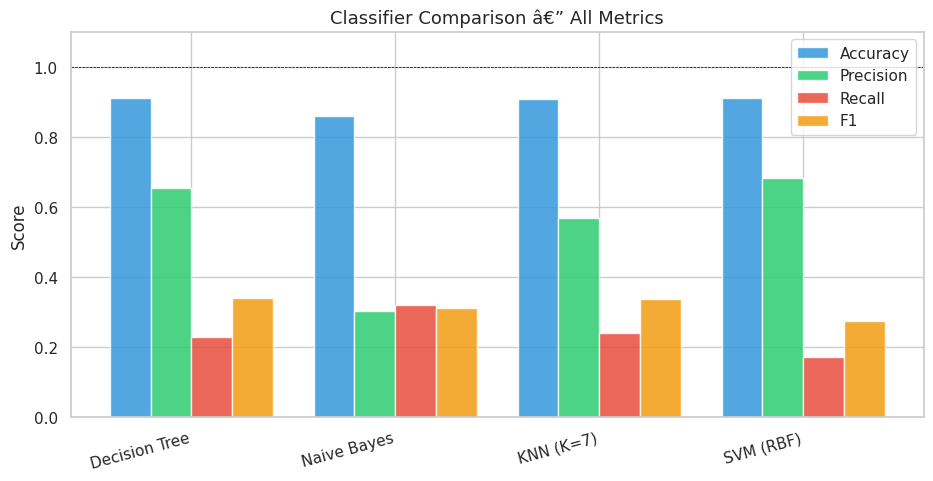

Saved: /content/plots/classifier_comparison.png


In [48]:
fig, ax = plt.subplots(figsize=(11, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(results_df))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_title('Classifier Comparison â€” All Metrics', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.5)
plt.show()
save_fig('classifier_comparison.png')

K=2: Inertia=195844
K=3: Inertia=165526
K=4: Inertia=140484
K=5: Inertia=117772
K=6: Inertia=104007
K=7: Inertia=92793
K=8: Inertia=84501
K=9: Inertia=79091
K=10: Inertia=75427


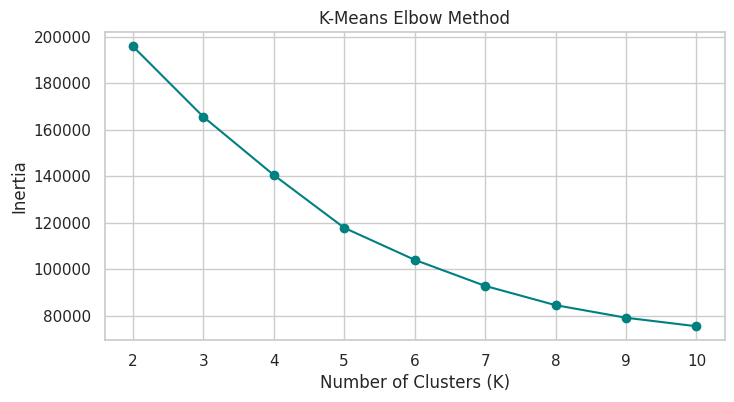

Saved: /content/plots/kmeans_elbow.png


In [50]:
# Use a sample for clustering
cluster_sample_size = 30000
np.random.seed(42)
cluster_idx = np.random.choice(len(X), size=min(cluster_sample_size, len(X)), replace=False)
X_cluster = scaler.transform(X[cluster_idx])

# Elbow Method â€” choose optimal K
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    print(f'K={k}: Inertia={km.inertia_:.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, marker='o', color='teal')
ax.set_title('K-Means Elbow Method')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
plt.show()
save_fig('kmeans_elbow.png')

In [51]:
# Fit best K-Means
BEST_K = 4
km_best = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_cluster)

sil = silhouette_score(X_cluster, cluster_labels, sample_size=5000, random_state=42)
print(f'Silhouette Score (K={BEST_K}): {sil:.4f}')

Silhouette Score (K=4): 0.2737


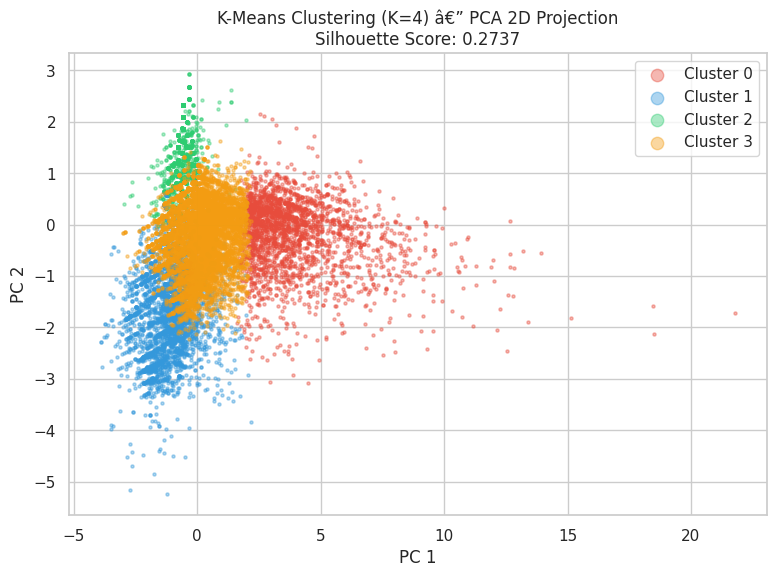

Saved: /content/plots/kmeans_pca_clusters.png


In [52]:
# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

fig, ax = plt.subplots(figsize=(9, 6))
scatter_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for c in range(BEST_K):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=5, alpha=0.4,
               color=scatter_colors[c], label=f'Cluster {c}')
ax.set_title(f'K-Means Clustering (K={BEST_K}) â€” PCA 2D Projection\nSilhouette Score: {sil:.4f}')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(markerscale=4)
plt.show()
save_fig('kmeans_pca_clusters.png')

In [53]:
# Cluster profile â€” mean feature values per cluster
cluster_df = pd.DataFrame(X[cluster_idx], columns=FEATURES)
cluster_df['Cluster'] = cluster_labels
cluster_profile = cluster_df.groupby('Cluster').mean()
print('Cluster Profiles (mean feature values):')
cluster_profile

Cluster Profiles (mean feature values):


,HEIGHT,SPEED,DISTANCE,AC_MASS,NUM_STRUCK,SIZE_ENC,PHASE_OF_FLIGHT_ENC,TIME_OF_DAY_ENC,AC_CLASS_ENC
Cluster,,,,,,,,,
0,4810.616553,210.554578,8.428852,3.848461,1.0,1.685326,1.015594,2.572571,0.002399
1,512.664051,112.257722,0.323572,1.643291,1.0,1.537722,3.946329,1.717975,0.390380
2,44.056740,138.825934,0.000000,3.907357,1.0,1.854624,10.920180,3.859272,0.002565
3,328.691334,139.118198,0.289660,3.810919,1.0,1.780300,2.964471,1.662276,0.000462


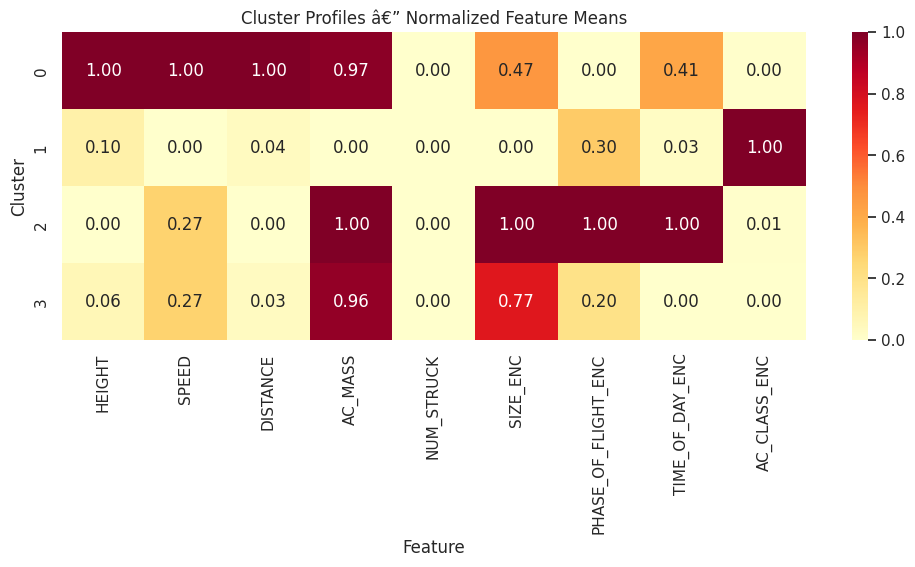

Saved: /content/plots/cluster_profiles_heatmap.png


In [55]:
# Heatmap of cluster profiles
from sklearn.preprocessing import MinMaxScaler
profile_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Cluster Profiles â€” Normalized Feature Means')
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.show()
save_fig('cluster_profiles_heatmap.png')

In [56]:
# Build transactions from categorical features
arm_df = df[['SIZE', 'PHASE_OF_FLIGHT', 'DAMAGE_LEVEL', 'TIME_OF_DAY', 'AC_CLASS']].copy()
arm_df = arm_df.dropna()
arm_df = arm_df[arm_df['DAMAGE_LEVEL'].isin(['N', 'M', 'M?', 'S', 'D'])]
arm_df['DAMAGE_LEVEL'] = arm_df['DAMAGE_LEVEL'].replace({'M?': 'M'})

# Create item strings
arm_df['SIZE_ITEM']   = 'Size=' + arm_df['SIZE'].astype(str)
arm_df['PHASE_ITEM']  = 'Phase=' + arm_df['PHASE_OF_FLIGHT'].astype(str)
arm_df['DAMAGE_ITEM'] = 'Damage=' + arm_df['DAMAGE_LEVEL'].astype(str)
arm_df['TOD_ITEM']    = 'TOD=' + arm_df['TIME_OF_DAY'].astype(str)
arm_df['CLASS_ITEM']  = 'AcClass=' + arm_df['AC_CLASS'].astype(str)

transactions = arm_df[['SIZE_ITEM', 'PHASE_ITEM', 'DAMAGE_ITEM', 'TOD_ITEM', 'CLASS_ITEM']].values.tolist()

print(f'Total transactions: {len(transactions):,}')
print('Sample transaction:', transactions[0])

Total transactions: 146,024
Sample transaction: ['Size=Medium', 'Phase=Take-off Run', 'Damage=N', 'TOD=Day', 'AcClass=A  ']


In [57]:
# Encode for Apriori
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
te_df = pd.DataFrame(te_array, columns=te.columns_)

# Mine frequent itemsets
frequent_itemsets = apriori(te_df, min_support=0.05, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f'Frequent itemsets found: {len(frequent_itemsets)}')
frequent_itemsets.sort_values('support', ascending=False).head(10)

Frequent itemsets found: 119


,support,itemsets,length
0,0.972840,(AcClass=A ),1
2,0.890450,(Damage=N),1
13,0.868837,"(AcClass=A , Damage=N)",2
9,0.649695,(Size=Small),1
20,0.632006,"(AcClass=A , Size=Small)",2
28,0.627226,"(Damage=N, Size=Small)",2
50,0.610831,"(Damage=N, AcClass=A , Size=Small)",3
10,0.605339,(TOD=Day),1
21,0.594765,"(TOD=Day, AcClass=A )",2
29,0.541384,"(TOD=Day, Damage=N)",2


In [58]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.4, num_itemsets=len(frequent_itemsets))
rules = rules.sort_values('lift', ascending=False)
print(f'Rules generated: {len(rules)}')

# Show top rules with Damage in consequent
damage_rules = rules[rules['consequents'].astype(str).str.contains('Damage')]
print(f'Rules with Damage in consequent: {len(damage_rules)}')
damage_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

Rules generated: 448
Rules with Damage in consequent: 179


,antecedents,consequents,support,confidence,lift
377,"(Phase=Approach, Size=Medium)","(AcClass=A , Damage=N, TOD=Night)",0.056854,0.459843,1.733480
397,"(AcClass=A , Size=Small, TOD=Night)","(Phase=Approach, Damage=N)",0.114700,0.686688,1.711843
374,"(Phase=Approach, AcClass=A , Size=Medium)","(Damage=N, TOD=Night)",0.056854,0.463851,1.665929
332,"(Phase=Approach, Size=Medium)","(Damage=N, TOD=Night)",0.057244,0.463000,1.662873
346,"(Size=Small, TOD=Night)","(Phase=Approach, Damage=N)",0.116214,0.651265,1.623536
403,"(Size=Small, TOD=Night)","(Phase=Approach, AcClass=A , Damage=N)",0.114700,0.642783,1.615076
217,(Phase=Approach),"(AcClass=A , Damage=N, TOD=Night)",0.179176,0.402938,1.518966
215,"(AcClass=A , TOD=Night)","(Phase=Approach, Damage=N)",0.179176,0.599391,1.494220
443,"(Phase=Take-off Run, Size=Small)","(AcClass=A , TOD=Day, Damage=N)",0.080240,0.794265,1.488091
428,"(Phase=Landing Roll, Size=Small)","(AcClass=A , TOD=Day, Damage=N)",0.109900,0.789414,1.479002


In [59]:
# Scatter plot: Support vs Confidence coloured by Lift
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd', alpha=0.7, s=40
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_title('Association Rules â€” Support vs Confidence (color=Lift)')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
plt.tight_layout()
save_fig('association_rules_scatter.png')

Saved: /content/plots/association_rules_scatter.png


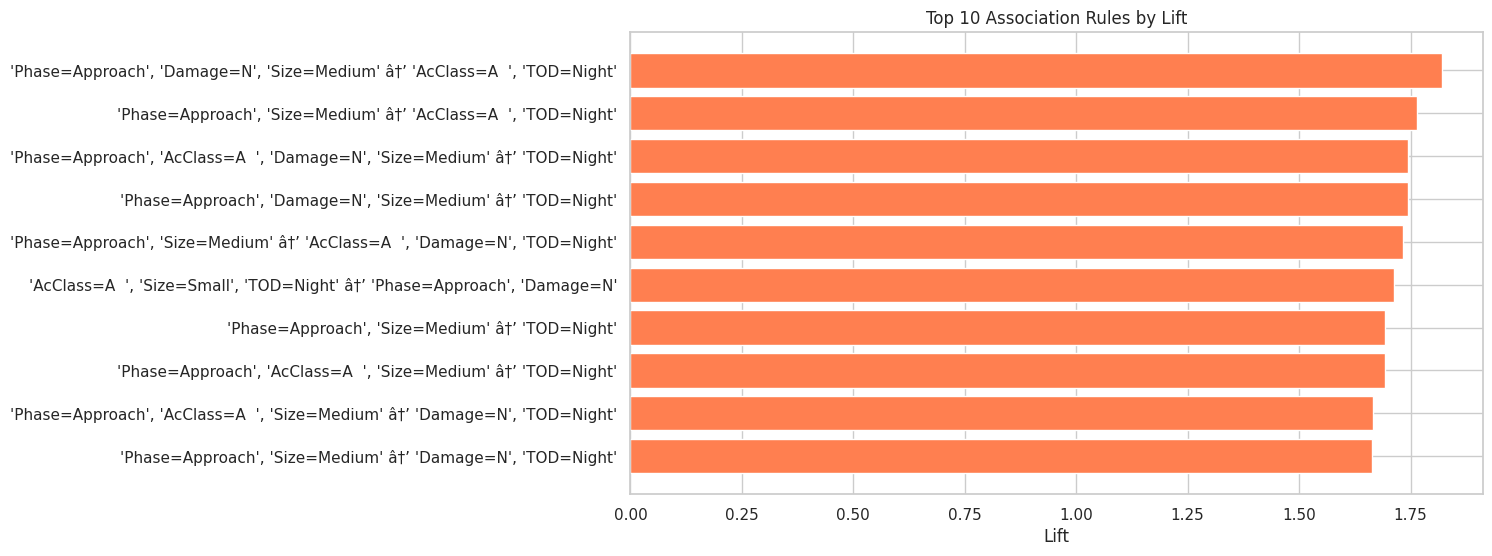

Saved: /content/plots/top_association_rules.png


In [62]:
# Top 10 rules by lift (bar chart)
top_rules = rules.head(10).copy()
top_rules['rule'] = [
    f"{str(list(a))[1:-1]} â†’ {str(list(c))[1:-1]}"
    for a, c in zip(top_rules['antecedents'], top_rules['consequents'])
]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_rules['rule'][::-1], top_rules['lift'][::-1], color='coral')
ax.set_title('Top 10 Association Rules by Lift')
ax.set_xlabel('Lift')
plt.show()
save_fig('top_association_rules.png')

In [63]:
# Use full preprocessed feature set
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso_labels = iso.fit_predict(X_train_s_sc)  # -1 = anomaly, 1 = normal

anomaly_rate = (iso_labels == -1).mean()
print(f'Anomaly rate in training sample: {anomaly_rate:.2%}')
print(f'Anomalies: {(iso_labels==-1).sum():,} | Normal: {(iso_labels==1).sum():,}')
iso_lbl = iso_labels  # alias used in next cell


Anomaly rate in training sample: 5.00%
Anomalies: 2,500 | Normal: 47,500


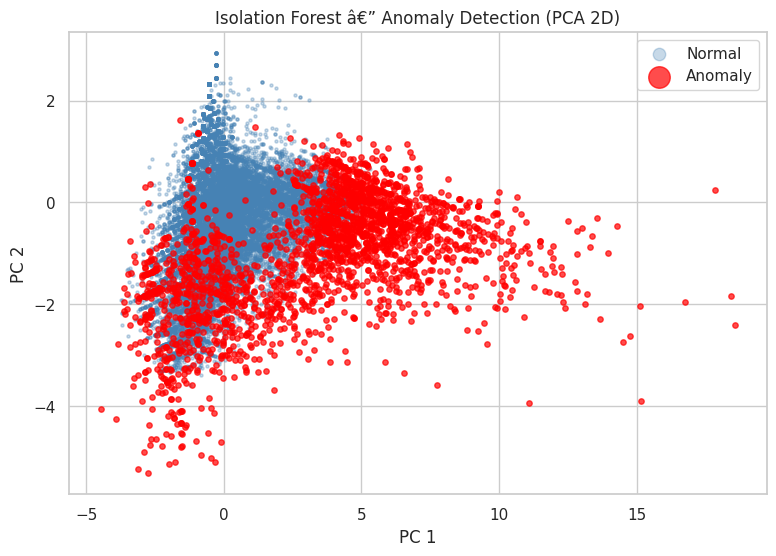

Saved: /content/plots/anomaly_detection_pca.png


In [65]:
# PCA visualization of anomalies
pca_iso = PCA(n_components=2, random_state=42)
X_iso_pca = pca_iso.fit_transform(X_train_s_sc)

fig, ax = plt.subplots(figsize=(9, 6))
normal_mask  = iso_labels == 1
anomaly_mask = iso_labels == -1
ax.scatter(X_iso_pca[normal_mask, 0],  X_iso_pca[normal_mask, 1],
           s=5, alpha=0.3, color='steelblue', label='Normal')
ax.scatter(X_iso_pca[anomaly_mask, 0], X_iso_pca[anomaly_mask, 1],
           s=15, alpha=0.7, color='red', label='Anomaly')
ax.set_title('Isolation Forest â€” Anomaly Detection (PCA 2D)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(markerscale=4)
plt.show()
save_fig('anomaly_detection_pca.png')

In [66]:
# Profile anomalies vs normal
anomaly_df = pd.DataFrame(X_train_s, columns=FEATURES)
anomaly_df['ANOMALY'] = (iso_labels == -1).astype(int)

profile_compare = anomaly_df.groupby('ANOMALY')[['HEIGHT', 'SPEED', 'DISTANCE', 'AC_MASS']].mean()
profile_compare.index = ['Normal', 'Anomaly']
print('Feature means: Normal vs Anomalous incidents')
print(profile_compare)

Feature means: Normal vs Anomalous incidents
              HEIGHT       SPEED  DISTANCE   AC_MASS
Normal    446.497958  139.288168  0.406056  3.578232
Anomaly  4863.871200  183.009600  9.788220  3.078400


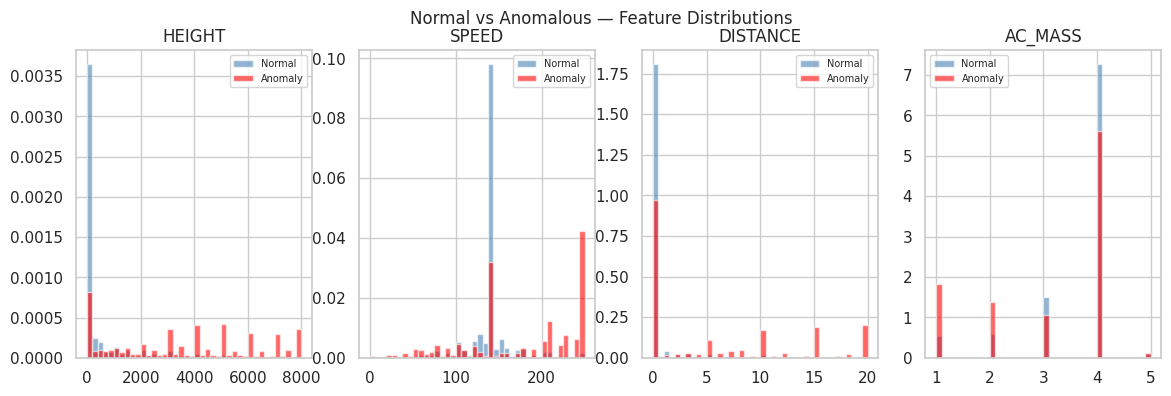

Saved: /content/plots/anomaly_feature_distributions.png


In [68]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, ["HEIGHT","SPEED","DISTANCE","AC_MASS"]):
    ci2 = FEATURES.index(col)
    all_v = X_tr_s[:, ci2].astype(float)
    cap = float(np.percentile(all_v, 99))
    norm_v = all_v[(iso_lbl== 1) & (all_v <= cap)]
    anom_v = all_v[(iso_lbl==-1) & (all_v <= cap)]
    ax.hist(norm_v, bins=40, alpha=0.6, color="steelblue", label="Normal",  density=True)
    ax.hist(anom_v, bins=40, alpha=0.6, color="red",       label="Anomaly", density=True)
    ax.set_title(col); ax.legend(fontsize=7)
plt.suptitle("Normal vs Anomalous — Feature Distributions", fontsize=12)
plt.show()
save_fig("anomaly_feature_distributions.png")

In [69]:
print('='*65)
print('CLASSIFICATION RESULTS SUMMARY')
print('='*65)
print(results_df[['Accuracy', 'Precision', 'Recall', 'F1']].to_string())
print()
best_model = results_df['F1'].idxmax()
print(f'Best model by F1-Score: {best_model}')
print()
print('='*65)
print('CLUSTERING SUMMARY')
print('='*65)
print(f'Optimal K: {BEST_K} clusters')
print(f'Silhouette Score: {sil:.4f}')
print()
print('='*65)
print('ASSOCIATION RULES SUMMARY')
print('='*65)
print(f'Total rules mined: {len(rules)}')
print(f'Rules predicting Damage: {len(damage_rules)}')
if len(damage_rules) > 0:
    top_rule = damage_rules.iloc[0]
    print(f'Top rule: {set(top_rule["antecedents"])} â†’ {set(top_rule["consequents"])}')
    print(f'  Confidence: {top_rule["confidence"]:.3f} | Lift: {top_rule["lift"]:.3f}')
print()
print('='*65)
print('ANOMALY DETECTION SUMMARY')
print('='*65)
print(f'Contamination rate: 5%')
print(f'Anomalies detected: {(iso_labels==-1).sum():,} out of {len(iso_labels):,}')

CLASSIFICATION RESULTS SUMMARY
               Accuracy  Precision    Recall        F1
Model                                                 
Decision Tree  0.912272   0.653543  0.229176  0.339353
Naive Bayes    0.860468   0.301870  0.319374  0.310376
KNN (K=7)      0.907363   0.568767  0.238840  0.336412
SVM (RBF)      0.910689   0.681239  0.172112  0.274798

Best model by F1-Score: Decision Tree

CLUSTERING SUMMARY
Optimal K: 4 clusters
Silhouette Score: 0.2737

ASSOCIATION RULES SUMMARY
Total rules mined: 448
Rules predicting Damage: 179
Top rule: {'Phase=Approach', 'Size=Medium'} â†’ {'AcClass=A  ', 'Damage=N', 'TOD=Night'}
  Confidence: 0.460 | Lift: 1.733

ANOMALY DETECTION SUMMARY
Contamination rate: 5%
Anomalies detected: 2,500 out of 50,000
